<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/C8_Aprendizaje_No_Supervisado_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Clase 8 - Aprendizaje No Supervisado
## Segmentación de Clientes con K-Means

**Autor:** Lionel Martinez

**Materia:** Aprendizaje Automático  
**Fecha:** Mayo 2026

---

## Objetivo

El objetivo de este trabajo es aplicar técnicas de aprendizaje no supervisado utilizando el algoritmo **K-Means** para identificar segmentos de clientes a partir de sus comportamientos de compra y navegación en un sitio web.

Se trabajará con un dataset de clientes que contiene variables relacionadas con:
- frecuencia de compra
- ticket promedio
- tiempo de permanencia en el sitio
- sensibilidad a descuentos
- tasa de devoluciones

Además, se utilizarán:
- escalado de variables
- método del codo
- Silhouette Score
- análisis de centroides
- visualizaciones de clusters


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



# 1. Carga del Dataset

Se carga el dataset proporcionado en el campus virtual.


In [5]:

clientes_data = pd.read_csv('dataset_segmentacion_clientes.csv')

clientes_data.head()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522



# 2. Exploración de Datos

En esta sección analizamos:
- estructura del dataset
- tipos de variables
- estadísticas descriptivas
- valores nulos


In [6]:

clientes_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [7]:

clientes_data.describe()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


In [8]:

clientes_data.isnull().sum()


,0
purchase_freq_month,0
avg_basket_usd,0
time_on_site_min,0
discount_sensitivity,0
returns_rate,0
noise_gauss,0
noise_uniform,0



# 3. Selección de Variables

Se utilizarán únicamente las variables relevantes para el clustering.

Las columnas de ruido (`noise_gauss` y `noise_uniform`) no se utilizarán ya que podrían afectar negativamente el rendimiento del modelo.


In [9]:

features = [
    'purchase_freq_month',
    'avg_basket_usd',
    'time_on_site_min',
    'discount_sensitivity',
    'returns_rate'
]

X = clientes_data[features]

X.head()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,11.152508,181.300834,33.564036,1.000000,0.800000
1,12.053451,178.637272,35.432081,0.784974,0.000000
2,2.203006,450.185298,7.030757,0.898297,0.000000
3,4.233314,89.006342,10.834453,0.000000,0.800000
4,1.716799,449.773982,7.254548,0.000000,0.003279



# 4. Escalado de Variables

K-Means utiliza distancias euclidianas, por lo tanto es importante escalar las variables para evitar que aquellas con escalas mayores dominen el agrupamiento.


In [10]:

scaler = StandardScaler()

clientes_scaled = scaler.fit_transform(X)

clientes_scaled[:5]


array([[ 1.18104766, -0.43201153,  1.3002238 ,  1.33342344,  1.29867122],
       [ 1.38269638, -0.4492187 ,  1.44497872,  0.83470573, -0.9461957 ],
       [-0.82202607,  1.30503906, -0.75584112,  1.09754027, -0.9461957 ],
       [-0.36760354, -1.02825349, -0.46109255, -0.98590965,  1.29867122],
       [-0.93084879,  1.30238187, -0.73849955, -0.98590965, -0.93699568]])


# 5. Método del Codo

Se prueba el algoritmo K-Means para diferentes valores de k entre 2 y 6 para encontrar una cantidad razonable de clusters.


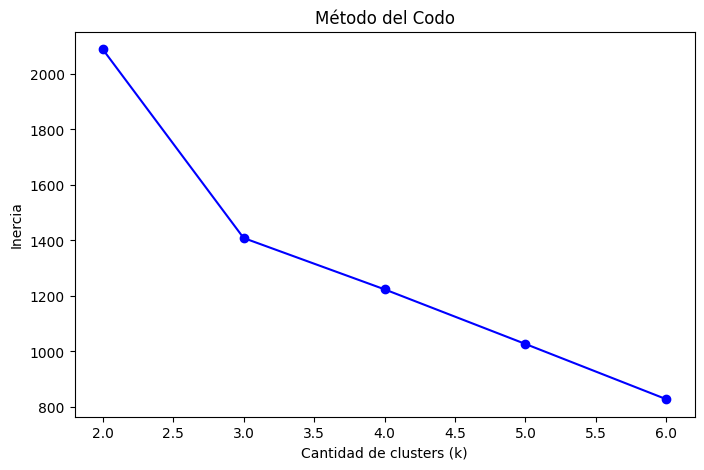

In [11]:

inertia = []

K = range(2, 7)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clientes_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, 'bo-')

plt.xlabel('Cantidad de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')

plt.show()



# 6. Entrenamiento del Modelo K-Means

A partir del método del codo se selecciona k=3 como valor razonable.


In [12]:

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clientes_data['cluster'] = kmeans.fit_predict(clientes_scaled)

clientes_data.head()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,2
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,1



# 7. Validación del Modelo

Se utiliza el **Silhouette Score** para evaluar la calidad del agrupamiento.


In [13]:

score = silhouette_score(
    clientes_scaled,
    clientes_data['cluster']
)

print("Silhouette Score:", score)


Silhouette Score: 0.4305114235798075



# 8. Análisis de Centroides

Los centroides permiten interpretar las características promedio de cada cluster.


In [14]:

centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centroides


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.846908,450.123746,5.973739,0.358088,0.375371
2,4.091883,89.957567,10.003793,0.379465,0.298761


In [15]:

clientes_data.groupby('cluster')[features].mean()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.846908,450.123746,5.973739,0.358088,0.375371
2,4.091883,89.957567,10.003793,0.379465,0.298761



# 9. Visualización de Clusters


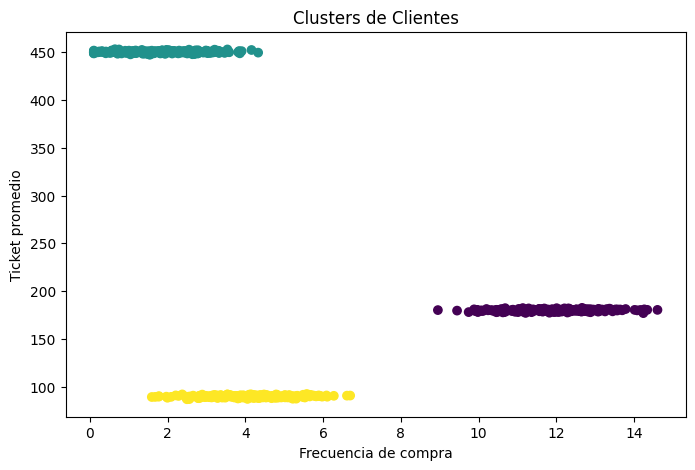

In [16]:

plt.figure(figsize=(8,5))

plt.scatter(
    clientes_data['purchase_freq_month'],
    clientes_data['avg_basket_usd'],
    c=clientes_data['cluster']
)

plt.xlabel('Frecuencia de compra')
plt.ylabel('Ticket promedio')
plt.title('Clusters de Clientes')

plt.show()


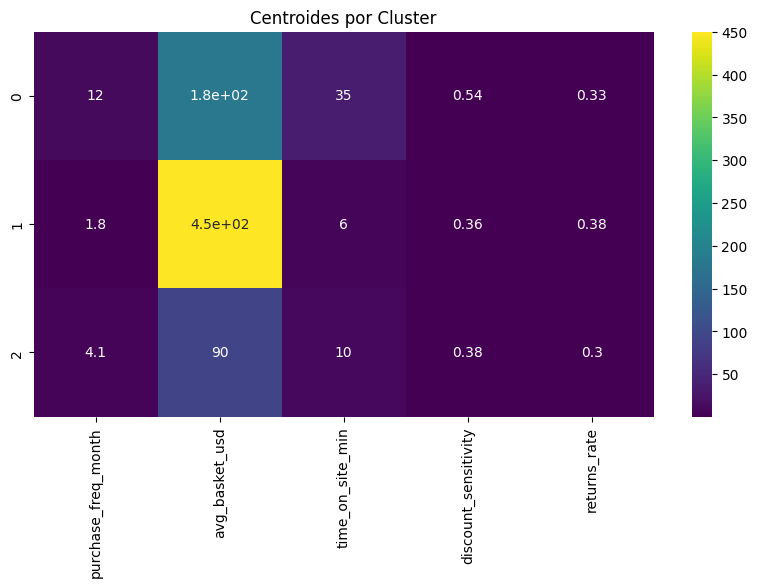

In [17]:

plt.figure(figsize=(10,5))

sns.heatmap(
    centroides,
    annot=True,
    cmap='viridis'
)

plt.title('Centroides por Cluster')

plt.show()



# 10. Reducción de Dimensionalidad con PCA

Se utiliza PCA para visualizar los clusters en dos dimensiones.


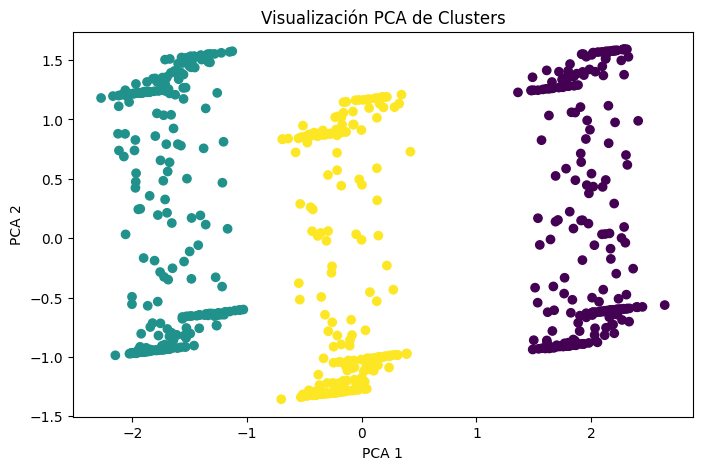

In [18]:

pca = PCA(n_components=2)

clientes_pca = pca.fit_transform(clientes_scaled)

plt.figure(figsize=(8,5))

plt.scatter(
    clientes_pca[:,0],
    clientes_pca[:,1],
    c=clientes_data['cluster']
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualización PCA de Clusters')

plt.show()



# 11. Interpretación de Clusters

### Cluster 0
- Alta frecuencia de compra
- Ticket promedio medio
- Sensibilidad media a descuentos

**Estrategia sugerida:** promociones y fidelización.

---

### Cluster 1
- Baja frecuencia de compra
- Ticket promedio alto
- Baja sensibilidad a descuentos

**Estrategia sugerida:** upselling y productos premium.

---

### Cluster 2
- Mayor tiempo de permanencia en el sitio
- Tasa de devoluciones más elevada

**Estrategia sugerida:** mejorar experiencia de usuario y reducir devoluciones.



# 12. Conclusión

El algoritmo K-Means permitió identificar distintos segmentos de clientes a partir de sus comportamientos de compra y navegación.

El método del codo sugirió utilizar 3 clusters y el Silhouette Score confirmó una separación adecuada entre grupos.

Además, el análisis de centroides permitió interpretar perfiles de clientes útiles para estrategias comerciales y de marketing.

Este proyecto demuestra cómo aplicar técnicas de aprendizaje no supervisado para descubrir patrones ocultos en los datos y generar información valiosa para la toma de decisiones.
